In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [2]:
def generateDataSet(range_start, range_end, num_samples = 1000, noise_std = 10.0):
    X = np.random.uniform(range_start, range_end, num_samples)
    noise = np.random.normal(0, noise_std, num_samples)
    y = 0.2 * X ** 6 - 0.5 * X ** 5 + 2 * X ** 4 - 5 * X ** 3 + 3 * X ** 2 - 10 * X + 5 + noise

    return X, y


X, y = generateDataSet(-3, 3)


Visualize the dataset

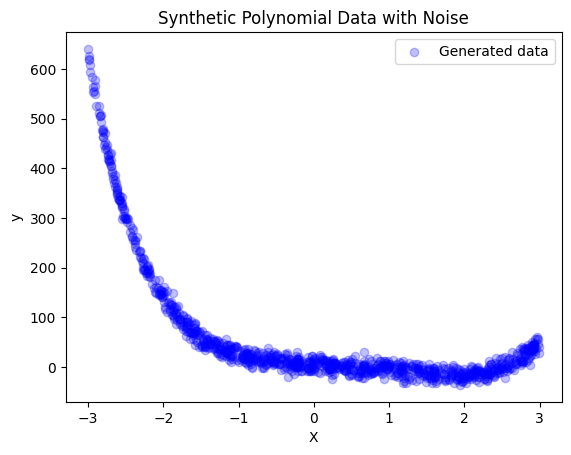

In [3]:

plt.scatter(X, y, color='b', alpha=0.25, label='Generated data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Polynomial Data with Noise')
plt.legend()
plt.show()

In [4]:
X_train, X_test_in_range, y_train, y_test_in_range = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
X_out, y_out = generateDataSet(5, 7)
_, X_test_out_of_range, _, y_test_out_of_range = train_test_split(X_out, y_out, test_size=0.2, random_state=42)

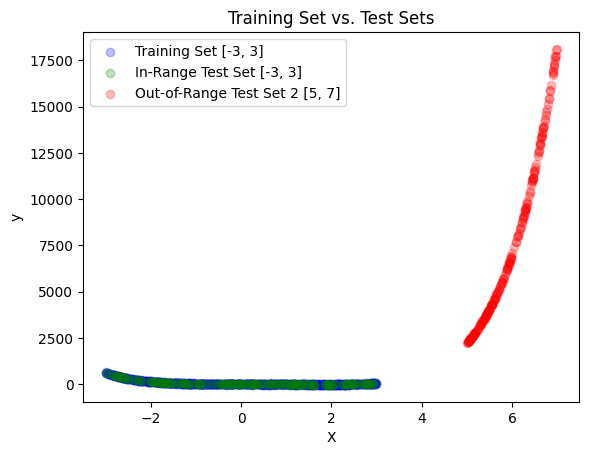

In [6]:
plt.scatter(X_train, y_train, color='blue', alpha=0.25, label='Training Set [-3, 3]')
plt.scatter(X_test_in_range, y_test_in_range, color='green', alpha=0.25, label='In-Range Test Set [-3, 3]')
plt.scatter(X_test_out_of_range, y_test_out_of_range, color='red', alpha=0.25, label='Out-of-Range Test Set 2 [5, 7]')
plt.legend()
plt.title('Training Set vs. Test Sets')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [7]:
def train_models(X, y, degree):
    features = PolynomialFeatures(degree=degree)
    lr = LinearRegression()

    model = make_pipeline(features, lr)
    model.fit(X.reshape(-1, 1), y)

    return model

In [8]:
models = {}
degree = 9

for d in range(2, degree + 1):
    models[d] = train_models(X_train, y_train, d)

In [9]:
def evaluate_models(models, X_test, y_test):
    losses = {}
    for degree, model in models.items():
        y_pred = model.predict(X_test.reshape(-1, 1))
        losses[degree] = mean_squared_error(y_test, y_pred)

    return losses

In [10]:
losses_train = evaluate_models(models, X_train, y_train)
losses_in_range = evaluate_models(models, X_test_in_range, y_test_in_range)
losses_out_of_range = evaluate_models(models, X_test_out_of_range, y_test_out_of_range)

Calculate the log MSE for both the train and the test sets based on the model degrees from 2 to 9

In [11]:
log_losses_train = np.log1p(list(losses_train.values()))
log_losses_in_range = np.log1p(list(losses_in_range.values()))
log_losses_out_of_range = np.log1p(list(losses_out_of_range.values()))

In [12]:
degrees = range(2, degree + 1)

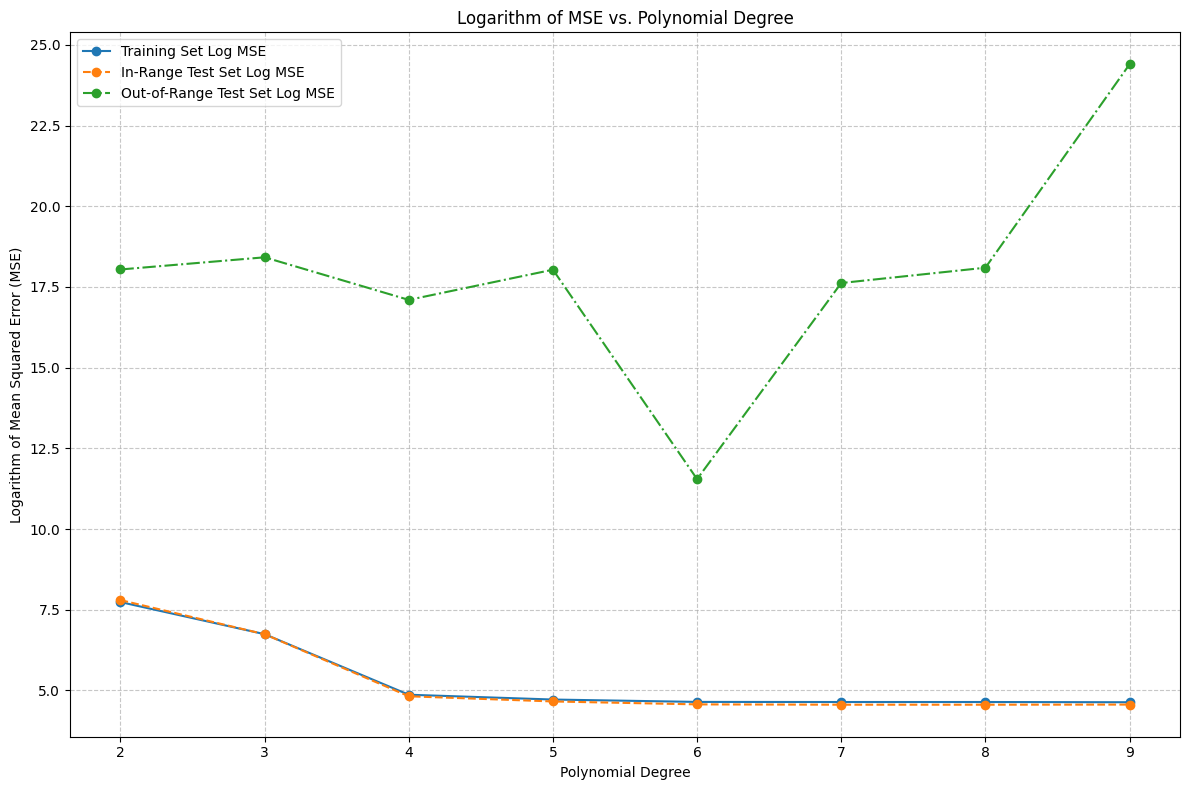

In [13]:
plt.figure(figsize=(12, 8))
plt.plot(degrees, list(log_losses_train), marker='o', linestyle='-', label='Training Set Log MSE')
plt.plot(degrees, list(log_losses_in_range), marker='o', linestyle='--', label='In-Range Test Set Log MSE')
plt.plot(degrees, list(log_losses_out_of_range), marker='o', linestyle='-.', label='Out-of-Range Test Set Log MSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('Logarithm of Mean Squared Error (MSE)')
plt.title('Logarithm of MSE vs. Polynomial Degree')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(degrees)
plt.tight_layout()
plt.show()

In [14]:
print(f"{'Degree':<10}{'Train MSE':<20}{'In-Range Test MSE':<20}{'Out-of-Range Test MSE':<20}")
for i in range(degree - 1):
    print(f"{i + 2:<10}{log_losses_train[i]:<20.2f}{log_losses_in_range[i]:<20.2f}{log_losses_out_of_range[i]:<20.2f}")

Degree    Train MSE           In-Range Test MSE   Out-of-Range Test MSE
2         7.74                7.80                18.04               
3         6.74                6.74                18.42               
4         4.87                4.82                17.10               
5         4.72                4.66                18.04               
6         4.64                4.57                11.55               
7         4.64                4.56                17.62               
8         4.64                4.56                18.10               
9         4.63                4.56                24.40               
